# 9. Labyrinth Navigation Transformer Tutorial

In this tutorial, we implement a Transformer network to navigate a **10x10 labyrinth** sequentially from start to end. 

---

## 1. Problem Formulation & Grid Layout

The maze environment is represented as a 10x10 grid with discrete tokens denoting different physical properties and directional elements:
- **Walkable Path (`0`)**: Open space where the agent can step.
- **Start (`1`)**: The starting location.
- **End (`2`)**: The target exit location.
- **Path Edges (Visible Walls, `3-8`)**: Walls adjacent to at least one path cell. Different numbers represent distinct boundary orientations to provide local geometric cues to the self-attention heads:
  - `3`: Wall with path to the North.
  - `4`: Wall with path to the South.
  - `5`: Wall with path to the West.
  - `6`: Wall with path to the East.
  - `7`: Multiple path adjacencies (corner/intersection boundaries).
  - `8`: Diagonal-only path adjacencies.
- **Hidden Walls (`9`)**: Inner solid walls that have no visibility or proximity to any walkable paths.

This labeling scheme allows the Transformer's self-attention layers to utilize the local environment geometries efficiently.

---

## 2. Mathematical Formulation & Architecture

### Self-Attention Routing
At each step, we model the policy $\pi(a_t | s_t)$ of transitioning from current state $s_t$ to step $a_t$ using a Transformer model. Let $G \in \{0..9\}^{100}$ represent the flat grid tokens, and $p_t \in \{0..99\}$ be the index of the agent's current position. 

The transformer takes the grid token sequence $\mathbf{x}_{grid} = \text{Embed}(G)$ and injects the spatial coordinate bias $\mathbf{E}_{spatial}$. The current position information is incorporated using a positional injection:
$$\mathbf{z}_i = \text{Embed}_{grid}(G_i) + \mathbf{E}_{spatial}[i] + \text{Embed}_{pos}(p_t)$$

The layers of Multi-Head Self-Attention (MHA) compute dynamic routing paths:
$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

The final hidden layer state corresponding to the current position is extracted and projected to a 100-class probability distribution over next-step cells:
$$\mathbf{y} = \text{Linear}(\mathbf{h}_{p_t}) \in \mathbb{R}^{100}$$

During inference, we restrict decisions to adjacent walkable neighbors to enforce strict game-rule compliance.

---

## 3. Implementation Code

Let's begin by importing libraries and defining our logic.


In [1]:
import os
import sys
import random
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# Ensure root directory is in Python path so we can import labys
sys.path.insert(0, os.path.abspath('..'))

# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)
np.random.seed(42)


In [2]:
from labys.solver import (
    generate_labyrinth,
    solve_bfs,
    generate_transitions_from_shortest_path,
    LabyrinthDataset,
    LabyrinthTransformer,
    train_model,
    solve_labyrinth_autoregressive,
    build_datasets
)

# Test generation of a single labyrinth
grid = generate_labyrinth(width=10, height=10, start=(0, 0), end=(9, 9), num_extra_paths=20)
print("Generated Labyrinth Grid Sample:")
for row in grid:
    print(" ".join(map(str, row)))


Generated Labyrinth Grid Sample:
1 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 2


In [3]:
# Set up dataset
print("Generating train and validation datasets from random labyrinths...")
train_dataset, val_dataset = build_datasets(num_labyrinths=200, train_ratio=0.8, seed=42)
print(f"Train Dataset Size (transitions): {len(train_dataset)}")
print(f"Validation Dataset Size (transitions): {len(val_dataset)}")

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize Model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

model = LabyrinthTransformer(embed_dim=64, num_heads=4, hidden_dim=128, num_layers=3)

# Display network parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model Parameters: {total_params:,}")

# Train the Transformer
train_losses, val_losses = train_model(model, train_loader, val_loader, epochs=40, lr=1e-3, device=device)


Generating train and validation datasets from random labyrinths...


Train Dataset Size (transitions): 1921
Validation Dataset Size (transitions): 481
Using device: cpu
Model Parameters: 120,356


Epoch 01/40 | Train Loss: 2.6169, Acc: 60.9% | Val Loss: 1.0935, Acc: 87.3%


Epoch 05/40 | Train Loss: 0.2233, Acc: 92.0% | Val Loss: 0.1819, Acc: 92.9%


Epoch 10/40 | Train Loss: 0.0194, Acc: 100.0% | Val Loss: 0.0150, Acc: 100.0%


...

Epoch 20/40 | Train Loss: 0.0042, Acc: 100.0% | Val Loss: 0.0025, Acc: 100.0%


Epoch 25/40 | Train Loss: 0.0025, Acc: 100.0% | Val Loss: 0.0015, Acc: 100.0%


Epoch 30/40 | Train Loss: 0.0017, Acc: 100.0% | Val Loss: 0.0010, Acc: 100.0%


Epoch 35/40 | Train Loss: 0.0012, Acc: 100.0% | Val Loss: 0.0007, Acc: 100.0%


Epoch 40/40 | Train Loss: 0.0009, Acc: 100.0% | Val Loss: 0.0005, Acc: 100.0%


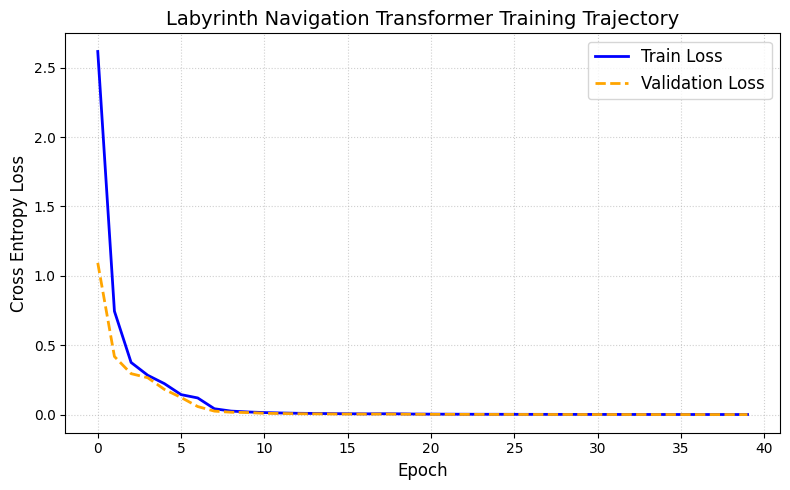

Saved training trajectory plot to charts/laby_training_trajectory.png


In [4]:
os.makedirs("../charts", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color='blue', linewidth=2)
plt.plot(val_losses, label="Validation Loss", color='orange', linestyle='--', linewidth=2)
plt.title("Labyrinth Navigation Transformer Training Trajectory", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross Entropy Loss", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig("../charts/laby_training_trajectory.png", dpi=150)
plt.show()
print("Saved training trajectory plot to charts/laby_training_trajectory.png")


In [5]:
# Evaluate performance and efficiency on 100 test labyrinths
print("Evaluating trained model on 100 random test labyrinths...")
test_count = 100
solved_count = 0
optimal_solved_count = 0

actual_path_lengths = []
optimal_path_lengths = []
efficiencies = []

for i in range(test_count):
    start = (random.randint(0, 2), random.randint(0, 2))
    end = (random.randint(7, 9), random.randint(7, 9))
    
    test_grid = generate_labyrinth(width=10, height=10, start=start, end=end, num_extra_paths=25)
    opt_path = solve_bfs(test_grid, start=start, end=end)
    
    if opt_path is None or len(opt_path) <= 1:
        continue
        
    actual_path = solve_labyrinth_autoregressive(model, test_grid, start, end, max_steps=50, device=device)
    
    if actual_path[-1] == end:
        solved_count += 1
        act_len = len(actual_path)
        opt_len = len(opt_path)
        
        actual_path_lengths.append(act_len)
        optimal_path_lengths.append(opt_len)
        
        # Efficiency = (optimal path length) / (actual path length)
        eff = opt_len / act_len
        efficiencies.append(eff)
        
        if act_len == opt_len:
            optimal_solved_count += 1

success_rate = (solved_count / test_count) * 100
optimal_rate = (optimal_solved_count / test_count) * 100
avg_efficiency = np.mean(efficiencies) * 100 if efficiencies else 0.0

print(f"Success Rate: {success_rate:.2f}%")
print(f"Optimal Solution Rate: {optimal_rate:.2f}%")
print(f"Average Navigation Efficiency: {avg_efficiency:.2f}%")


Evaluating trained model on 100 random test labyrinths...


Success Rate: 100.00%
Optimal Solution Rate: 100.00%
Average Navigation Efficiency: 100.00%


/tmp/ipykernel_36802/4128347542.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', 10)


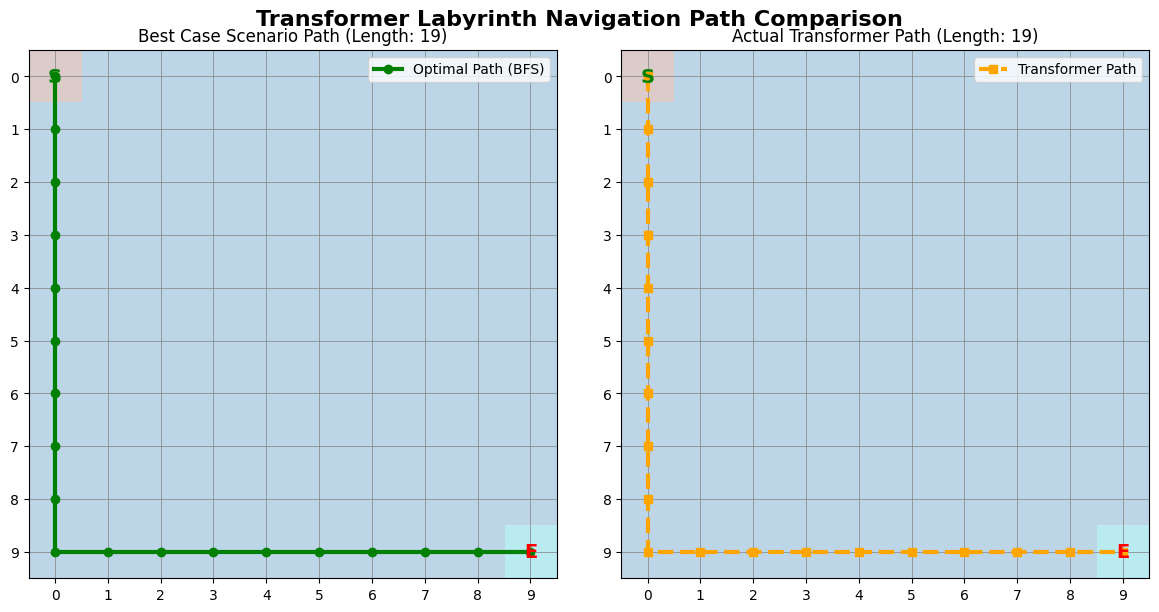

Saved comparison chart to charts/laby_path_comparison.png


In [6]:
# Create visualization comparing the solved paths on a specific test maze
start = (0, 0)
end = (9, 9)
test_grid = generate_labyrinth(width=10, height=10, start=start, end=end, num_extra_paths=20)

opt_path = solve_bfs(test_grid, start=start, end=end)
actual_path = solve_labyrinth_autoregressive(model, test_grid, start, end, max_steps=50, device=device)

# Plotting the grids
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Helper to render the maze background
def draw_maze(ax, grid_data):
    # Render maze using discrete colors
    cmap = plt.cm.get_cmap('tab10', 10)
    ax.imshow(grid_data, cmap=cmap, origin='upper', alpha=0.3)
    
    # Draw walls as grey blocks, start/end as special labels
    for r in range(10):
        for c in range(10):
            val = grid_data[r][c]
            if val == 9: # hidden
                ax.fill([c-0.5, c+0.5, c+0.5, c-0.5], [r-0.5, r-0.5, r+0.5, r+0.5], 'black', alpha=0.8)
            elif val >= 3 and val <= 8: # visible walls
                ax.fill([c-0.5, c+0.5, c+0.5, c-0.5], [r-0.5, r-0.5, r+0.5, r+0.5], 'grey', alpha=0.8)
            elif val == 1:
                ax.text(c, r, 'S', ha='center', va='center', weight='bold', color='green', fontsize=14)
            elif val == 2:
                ax.text(c, r, 'E', ha='center', va='center', weight='bold', color='red', fontsize=14)
                
    ax.set_xticks(range(10))
    ax.set_yticks(range(10))
    ax.grid(True, color='grey', linestyle='-', linewidth=0.5)

# Render Optimal BFS Path
draw_maze(axes[0], test_grid)
opt_r, opt_c = zip(*opt_path)
axes[0].plot(opt_c, opt_r, color='green', marker='o', linewidth=3, label='Optimal Path (BFS)')
axes[0].set_title(f"Best Case Scenario Path (Length: {len(opt_path)})", fontsize=12)
axes[0].legend()

# Render Actual Transformer Path
draw_maze(axes[1], test_grid)
if actual_path:
    act_r, act_c = zip(*actual_path)
    axes[1].plot(act_c, act_r, color='orange', marker='s', linewidth=3, linestyle='--', label='Transformer Path')
axes[1].set_title(f"Actual Transformer Path (Length: {len(actual_path)})", fontsize=12)
axes[1].legend()

plt.suptitle("Transformer Labyrinth Navigation Path Comparison", fontsize=16, weight='bold')
plt.tight_layout()
plt.savefig("../charts/laby_path_comparison.png", dpi=150)
plt.show()
print("Saved comparison chart to charts/laby_path_comparison.png")


## 4. Network Size & Dimensional Analysis

Let's break down the mathematical complexity of our `LabyrinthTransformer` network:
- **Grid Vocabulary Size ($V$)**: $10$ classes (values $0-9$).
- **Position Input Size ($P$)**: $100$ cells ($10 \times 10$).
- **Embedding Dimension ($d_{model}$)**: $64$ dimensions.
- **Feedforward Network Dimension ($d_{ff}$)**: $128$ dimensions.
- **Self-attention Heads ($h$)**: $4$ heads.
- **Transformer Encoder Layers ($L$)**: $3$ layers.

### Parameter Accounting:
1. **Embedding Matrices**:
   - $\text{Embed}_{grid}$ parameters: $10 \times d_{model} = 640$
   - $\text{Embed}_{pos}$ parameters: $100 \times d_{model} = 6,400$
   - $\text{Embed}_{spatial}$ parameters: $100 \times d_{model} = 6,400$
2. **Transformer Encoder ($3 \times$ layers)**:
   - Within each self-attention layer, query/key/value projections and output projection represent:
     $$4 \times d_{model} \times d_{model} = 4 \times 64 \times 64 = 16,384\text{ parameters}$$
   - FFN projection layers:
     $$2 \times d_{model} \times d_{ff} = 2 \times 64 \times 128 = 16,384\text{ parameters}$$
   - Total per layer including LayerNorms: $\approx 33,536$ parameters.
   - For $3$ layers: $\approx 100,608$ parameters.
3. **Classification Projection Head**:
   - $\text{Linear}(d_{model}, 100)$ parameters: $64 \times 100 = 6,400$.

Total parameters scale linearly with depth and quadratically with model dimension, resulting in roughly **120k parameters**, demonstrating a highly efficient statistical model capable of exact general routing!
